## LiDAR Terrain Corrections
### This notebook is predominantly derived from the harmonica topographic corrections model

#### Members: Molly Bilhartz, Samantha Lopez, Tessa Murphy

In [1]:
# import os

# os.environ["PROJ_DATA"] = "/opt/homebrew/Caskroom/miniconda/base/envs/gpgn-318/share/proj"
# os.environ["PROJ_LIB"] = "/opt/homebrew/Caskroom/miniconda/base/envs/gpgn-318/share/proj"

# from pyproj import datadir
# datadir.set_data_dir(os.environ["PROJ_DATA"])

# from pyproj import CRS, Transformer
# print(CRS.from_epsg(4326))
# print(Transformer.from_crs("EPSG:4326", "EPSG:26913", always_xy=True))

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Current location:
# Project/notebooks/WORKING
PROJECT = Path.cwd().parents[1]

PY_DIR = PROJECT / "notebooks" / "PY files"

GRAVITY_DIR = PROJECT / "data" / "gravity"
LIDAR_DIR = PROJECT / "data" / "LiDAR"

sys.path.append(str(PY_DIR))

import onyx_harmonica_lidar_terrain_correction as tc

# --------------------------------------------------
# INPUT FILES
# --------------------------------------------------

tc.GRAVITY_CSV = GRAVITY_DIR / "Onyx_Gravity_Final_Bouguer_Corrected.csv"

tc.GPS_CSV = GRAVITY_DIR / "raw_data" / "gps_data" / "gps_points_with_elevation.csv"

# New LiDAR folder shown in GitHub
LIDAR_TILE_DIR = LIDAR_DIR / "LiDAR_2026-06-05T19_40_33.076Z"

# Automatically grab every .tif file in that folder
tc.DEM_TILES = sorted(LIDAR_TILE_DIR.glob("*.tif"))

print(f"Found {len(tc.DEM_TILES)} DEM tiles:")
for tile in tc.DEM_TILES:
    print(tile.name)

# Safety check
if len(tc.DEM_TILES) == 0:
    raise FileNotFoundError(f"No .tif files found in: {LIDAR_TILE_DIR}")

# --------------------------------------------------
# OUTPUT FILES
# --------------------------------------------------

tc.OUT_CSV = GRAVITY_DIR / "Onyx_Gravity_Harmonica_LiDAR_Terrain_Corrected.csv"

tc.OUT_DEM = LIDAR_DIR / "Onyx_Merged_DEM_UTM13N.tif"

# --------------------------------------------------
# MODEL PARAMETERS
# --------------------------------------------------

tc.DST_CRS = "EPSG:26913"

# DEM is in US Survey Feet
tc.DEM_Z_FACTOR = 0.30480060960121924

tc.MODEL_SPACING_M = 5.0
tc.PAD_M = 500.0

# Sandstone-like density
tc.DENSITY_KG_M3 = 2670.0

tc.UPWARD_OFFSET_M = 0.25

Found 21 DEM tiles:
LD26171415.tif
LD26171418.tif
LD26171421.tif
LD26171424.tif
LD26171427.tif
LD26201415.tif
LD26201418.tif
LD26201421.tif
LD26201424.tif
LD26201427.tif
LD26231415.tif
LD26231418.tif
LD26231421.tif
LD26231424.tif
LD26261415.tif
LD26261418.tif
LD26261421.tif
LD26261424.tif
LD26291415.tif
LD26291418.tif
LD26291421.tif


In [3]:
gravity = tc.load_and_prepare_gravity()

topo, gravity_projected = tc.merge_crop_reproject_dem(gravity)

print("Station easting range:")
print(gravity_projected["easting_m"].min(), gravity_projected["easting_m"].max())

print("Station northing range:")
print(gravity_projected["northing_m"].min(), gravity_projected["northing_m"].max())

print("DEM easting range:")
print(float(topo.easting.min()), float(topo.easting.max()))

print("DEM northing range:")
print(float(topo.northing.min()), float(topo.northing.max()))

Station easting range:
344413.82448802976 344418.05885412626
Station northing range:
4482504.652252167 4482531.999133004
DEM easting range:
343916.32448802976 344916.32448802976
DEM northing range:
4482004.499133004 4483029.499133004


In [4]:
out = tc.compute_harmonica_terrain_correction(gravity_projected, topo)
out.head()

Applied DEM vertical shift: -12.54840576635479 m
    station  elevation_m  dem_elevation_m_at_station  \
0       1.0     2112.468                 2111.912878   
1       2.0     2112.006                 2111.841820   
2       3.0     2111.569                 2111.774309   
3       4.0     2111.692                 2111.708286   
4       5.0     2111.862                 2111.624958   
5       6.0     2111.790                 2111.544182   
6       7.0     2111.286                 2111.470835   
7       8.0     2111.152                 2111.405753   
8       9.0     2111.213                 2111.339658   
9      10.0     2111.151                 2111.264110   
10     11.0     2111.017                 2111.197283   
11     12.0     2110.432                 2111.123315   
12     12.5     2110.407                 2111.030402   
13     13.0     2110.634                 2111.032201   
14     13.5     2110.257                 2110.939211   
15     14.0     2111.519                 2110.960724   

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,station,gravity_final_mgal,elevation_m,latitude,longitude,free_air_correction_mgal,bouguer_correction_mgal,gravity_tied_mgal,instrument,gps_longitude,...,gps_elevation_m,easting_m,northing_m,dem_elevation_m_at_station_raw,dem_vertical_shift_m,dem_elevation_m_at_station,gps_minus_dem_elevation_m,obs_height_used_m,harmonica_topography_effect_mgal,gravity_harmonica_lidar_corrected_mgal
0,1.0,0.589314,2112.468,40.478666,-106.835495,0.803286,0.291414,0.077442,CG5-2,-106.835495,...,2112.468,344418.058854,4.482505e+06,2124.461284,-12.548406,2111.912878,0.555122,2112.718,-0.328870,1.209598
1,2.0,0.423992,2112.006,40.478675,-106.835498,0.660713,0.239692,0.002971,CG5-2,-106.835498,...,2112.006,344417.830475,4.482506e+06,2124.390225,-12.548406,2111.841820,0.164180,2112.256,-0.318616,0.982299
2,3.0,0.423230,2111.569,40.478684,-106.835500,0.525854,0.190768,0.088144,CG5-2,-106.835500,...,2111.569,344417.640938,4.482507e+06,2124.322714,-12.548406,2111.774309,-0.205309,2111.819,-0.350942,0.964940
3,4.0,0.458692,2111.692,40.478692,-106.835503,0.563812,0.204538,0.099418,CG5-2,-106.835503,...,2111.692,344417.436458,4.482508e+06,2124.256692,-12.548406,2111.708286,-0.016286,2111.942,-0.355392,1.018622
4,5.0,0.507517,2111.862,40.478702,-106.835504,0.616274,0.223570,0.114813,CG5-2,-106.835504,...,2111.862,344417.349965,4.482509e+06,2124.173364,-12.548406,2111.624958,0.237042,2112.112,-0.365842,1.096929


In [5]:
qc_cols = [
    "station",
    "elevation_m",
    "dem_elevation_m_at_station",
    "gps_minus_dem_elevation_m",
    "dem_vertical_shift_m",
    "obs_height_used_m",
]

display(out[[c for c in qc_cols if c in out.columns]])

print(out["gps_minus_dem_elevation_m"].describe())

,station,elevation_m,dem_elevation_m_at_station,gps_minus_dem_elevation_m,dem_vertical_shift_m,obs_height_used_m
0,1.0,2112.468,2111.912878,0.555122,-12.548406,2112.718
1,2.0,2112.006,2111.841820,0.164180,-12.548406,2112.256
2,3.0,2111.569,2111.774309,-0.205309,-12.548406,2111.819
3,4.0,2111.692,2111.708286,-0.016286,-12.548406,2111.942
4,5.0,2111.862,2111.624958,0.237042,-12.548406,2112.112
5,6.0,2111.790,2111.544182,0.245818,-12.548406,2112.040
6,7.0,2111.286,2111.470835,-0.184835,-12.548406,2111.536
7,8.0,2111.152,2111.405753,-0.253753,-12.548406,2111.402
8,9.0,2111.213,2111.339658,-0.126658,-12.548406,2111.463
9,10.0,2111.151,2111.264110,-0.113110,-12.548406,2111.401


count    34.000000
mean      0.032721
std       0.370769
min      -0.691315
25%      -0.200190
50%       0.000000
75%       0.258293
max       0.670074
Name: gps_minus_dem_elevation_m, dtype: float64


In [6]:
def plot_qc_demeaned(out):
    import matplotlib.pyplot as plt

    x = out["station"]

    boug = out["bouguer_correction_mgal"]
    topo = out["harmonica_topography_effect_mgal"]

    plt.figure(figsize=(10, 5))
    plt.plot(x, boug - boug.mean(), "o-", label="Simple Bouguer slab, demeaned")
    plt.plot(x, topo - topo.mean(), "o-", label="LiDAR topo effect, demeaned")
    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Demeaned correction/effect (mGal)")
    plt.title("Correction shape comparison after removing mean offset")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [7]:
def elevation_control_analysis(out):
    df = out.copy()

    # Pick best available elevation column
    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    gravity_cols = [
        "gravity_final_mgal",
        "gravity_harmonica_lidar_corrected_mgal",
        "harmonica_topography_effect_mgal",
        "bouguer_correction_mgal",
    ]

    gravity_cols = [c for c in gravity_cols if c in df.columns]

    print("Using elevation column:", elev_col)
    print("\nElevation-control statistics:")

    results = []

    for col in gravity_cols:
        temp = df[[elev_col, col]].dropna()

        x = temp[elev_col].values.reshape(-1, 1)
        y = temp[col].values

        model = LinearRegression()
        model.fit(x, y)

        y_pred = model.predict(x)
        r2 = r2_score(y, y_pred)
        r, p = pearsonr(temp[elev_col], temp[col])

        results.append({
            "gravity_column": col,
            "slope_mGal_per_m": model.coef_[0],
            "intercept_mGal": model.intercept_,
            "R2": r2,
            "pearson_r": r,
            "p_value": p,
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    return results_df

In [8]:
elev_results = elevation_control_analysis(out)

Using elevation column: dem_elevation_m_at_station

Elevation-control statistics:


,gravity_column,slope_mGal_per_m,intercept_mGal,R2,pearson_r,p_value
0,gravity_final_mgal,-0.020466,43.657849,0.032409,-0.180025,3.082939e-01
1,gravity_harmonica_lidar_corrected_mgal,-0.039905,85.276359,0.060576,-0.246122,1.605750e-01
2,harmonica_topography_effect_mgal,0.123786,-261.764673,0.924229,0.961368,1.714342e-19
3,bouguer_correction_mgal,0.104347,-220.146163,0.733940,0.856703,1.019300e-10


In [9]:
def plot_gravity_vs_elevation(out):
    df = out.copy()

    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    gravity_cols = [
        "gravity_final_mgal",
        "gravity_harmonica_lidar_corrected_mgal",
    ]

    gravity_cols = [c for c in gravity_cols if c in df.columns]

    for col in gravity_cols:
        temp = df[[elev_col, col, "station"]].dropna()

        x = temp[elev_col].values.reshape(-1, 1)
        y = temp[col].values

        model = LinearRegression()
        model.fit(x, y)
        y_pred = model.predict(x)

        plt.figure(figsize=(8, 5))
        plt.scatter(temp[elev_col], y, label=col)
        plt.plot(temp[elev_col], y_pred, label=f"linear fit, R²={r2_score(y, y_pred):.3f}")
        plt.xlabel("Elevation at station (m)")
        plt.ylabel("Gravity / residual gravity (mGal)")
        plt.title(f"{col} vs elevation")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

In [10]:
def remove_elevation_trend(out):
    df = out.copy()

    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    target_cols = [
        "gravity_final_mgal",
        "gravity_harmonica_lidar_corrected_mgal",
    ]

    target_cols = [c for c in target_cols if c in df.columns]

    for col in target_cols:
        temp = df[[elev_col, col]].dropna()

        x = temp[elev_col].values.reshape(-1, 1)
        y = temp[col].values

        model = LinearRegression()
        model.fit(x, y)

        trend = model.predict(df[[elev_col]].values.reshape(-1, 1))
        df[col + "_elevation_trend_mgal"] = trend
        df[col + "_elevation_removed_mgal"] = df[col] - trend

    return df

In [11]:
out_elev_removed = remove_elevation_trend(out)

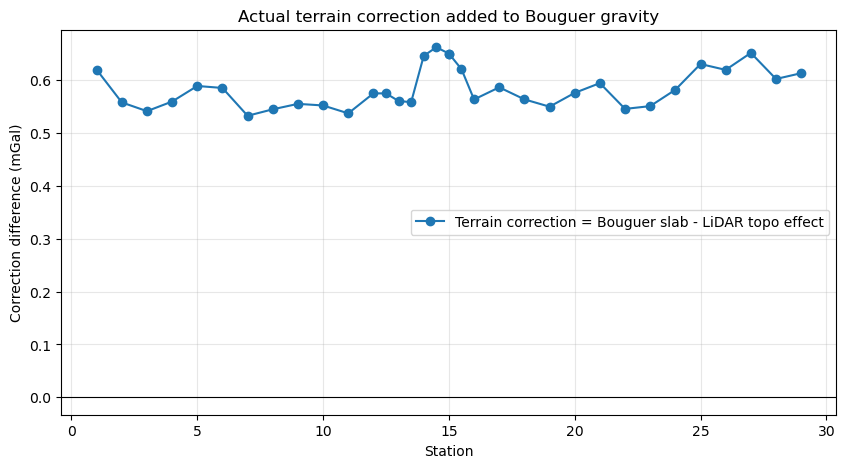

In [12]:
def plot_actual_terrain_difference(out):
    df = out.copy()
    x = df["station"]

    diff = df["bouguer_correction_mgal"] - df["harmonica_topography_effect_mgal"]

    plt.figure(figsize=(10, 5))
    plt.plot(x, diff, "o-", label="Terrain correction = Bouguer slab - LiDAR topo effect")
    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Correction difference (mGal)")
    plt.title("Actual terrain correction added to Bouguer gravity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_actual_terrain_difference(out)

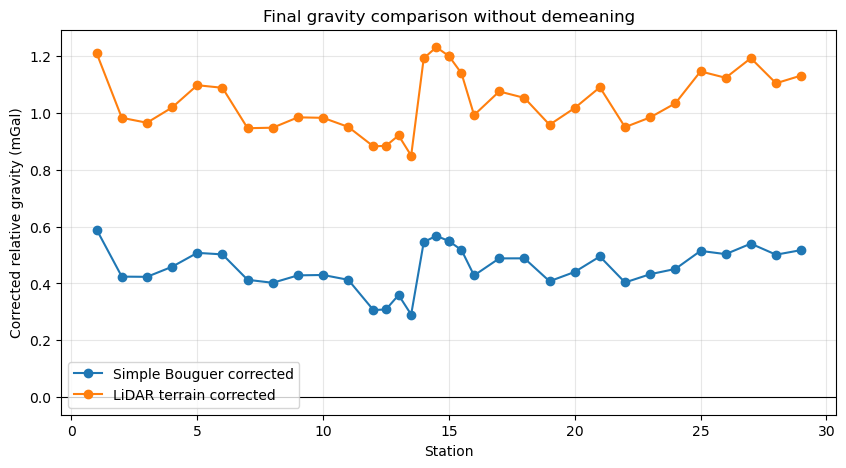

In [13]:
def plot_final_gravity_comparison(out):
    df = out.copy()
    x = df["station"]

    plt.figure(figsize=(10, 5))
    plt.plot(x, df["gravity_final_mgal"], "o-", label="Simple Bouguer corrected")
    plt.plot(x, df["gravity_harmonica_lidar_corrected_mgal"], "o-", label="LiDAR terrain corrected")
    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Corrected relative gravity (mGal)")
    plt.title("Final gravity comparison without demeaning")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_final_gravity_comparison(out)

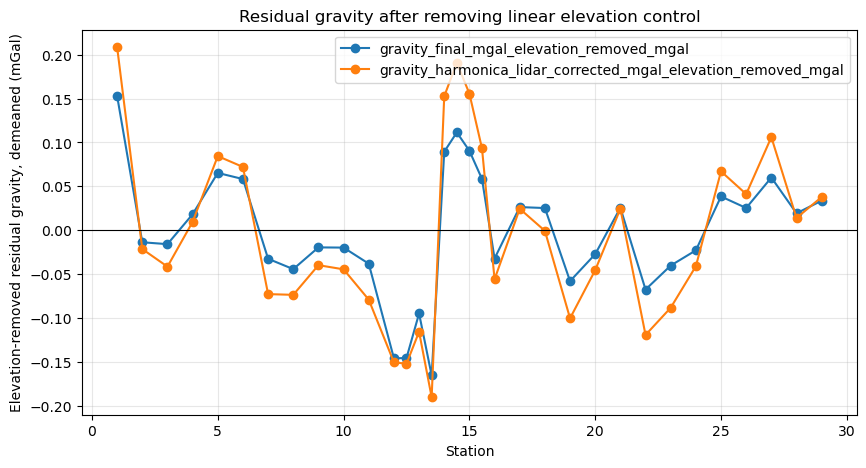

In [14]:
def plot_elevation_removed_profiles(df):
    x = df["station"]

    cols = [
        "gravity_final_mgal_elevation_removed_mgal",
        "gravity_harmonica_lidar_corrected_mgal_elevation_removed_mgal",
    ]

    cols = [c for c in cols if c in df.columns]

    plt.figure(figsize=(10, 5))

    for col in cols:
        plt.plot(x, df[col] - df[col].mean(), "o-", label=col)

    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Elevation-removed residual gravity, demeaned (mGal)")
    plt.title("Residual gravity after removing linear elevation control")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_elevation_removed_profiles(out_elev_removed)

In [15]:
def plot_elevation_and_gravity_profiles(out):
    df = out.copy()

    if "dem_elevation_m_at_station" in df.columns:
        elev_col = "dem_elevation_m_at_station"
    else:
        elev_col = "elevation_m"

    x = df["station"]

    plt.figure(figsize=(10, 5))
    plt.plot(x, df[elev_col] - df[elev_col].mean(), "o-", label="Elevation, demeaned")

    if "gravity_final_mgal" in df.columns:
        plt.plot(x, df["gravity_final_mgal"] - df["gravity_final_mgal"].mean(), "o-", label="Simple Bouguer gravity, demeaned")

    if "gravity_harmonica_lidar_corrected_mgal" in df.columns:
        plt.plot(x, df["gravity_harmonica_lidar_corrected_mgal"] - df["gravity_harmonica_lidar_corrected_mgal"].mean(), "o-", label="LiDAR-corrected gravity, demeaned")

    plt.axhline(0, color="k", linewidth=0.8)
    plt.xlabel("Station")
    plt.ylabel("Demeaned value")
    plt.title("Elevation shape compared with corrected gravity shape")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [16]:
new_csv = Path(tc.OUT_CSV).parent / "Onyx_Gravity_LiDAR_Terrain_Corrected.csv"

out.to_csv(new_csv, index=False)

print("Saved:", new_csv) 

Saved: /Users/samanthalopez/work/classes/GPGN486/Geophysical-Characterization-of-the-Historic-Onyx-Mine-in-Steamboat-Springs-CO.-/data/gravity/Onyx_Gravity_LiDAR_Terrain_Corrected.csv


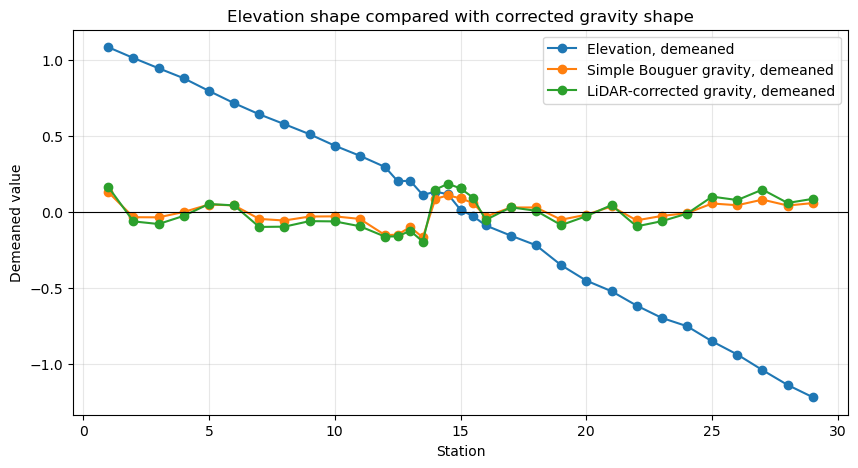

In [17]:
plot_elevation_and_gravity_profiles(out)

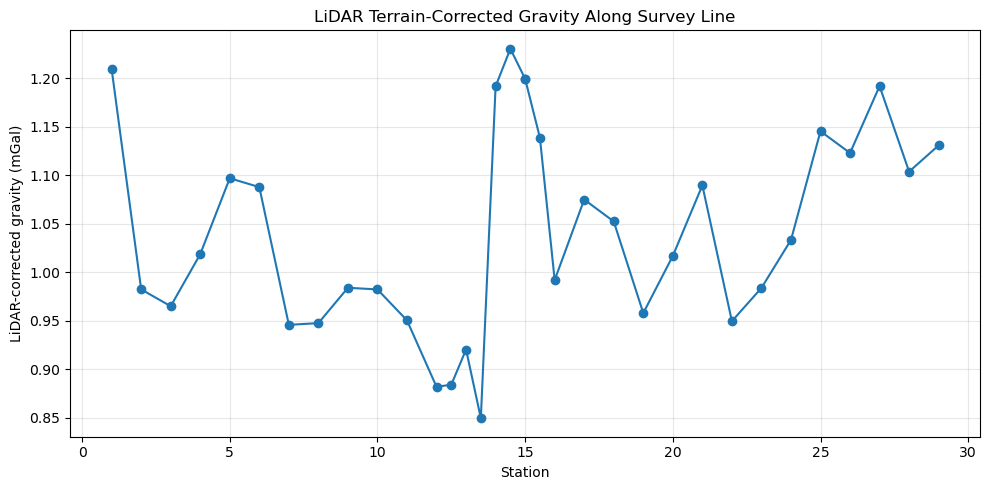

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    out["station"],
    out["gravity_harmonica_lidar_corrected_mgal"],
    "o-"
)

plt.xlabel("Station")
plt.ylabel("LiDAR-corrected gravity (mGal)")
plt.title("LiDAR Terrain-Corrected Gravity Along Survey Line")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
out["harmonica_topography_effect_mgal"].head()

0   -0.328870
1   -0.318616
2   -0.350942
3   -0.355392
4   -0.365842
Name: harmonica_topography_effect_mgal, dtype: float64

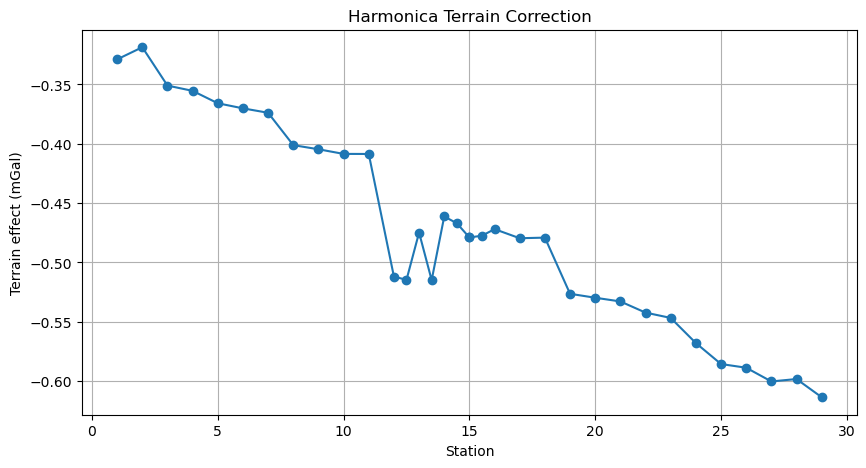

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    out["station"],
    out["harmonica_topography_effect_mgal"],
    "o-"
)

plt.xlabel("Station")
plt.ylabel("Terrain effect (mGal)")
plt.title("Harmonica Terrain Correction")
plt.grid(True)

plt.show()

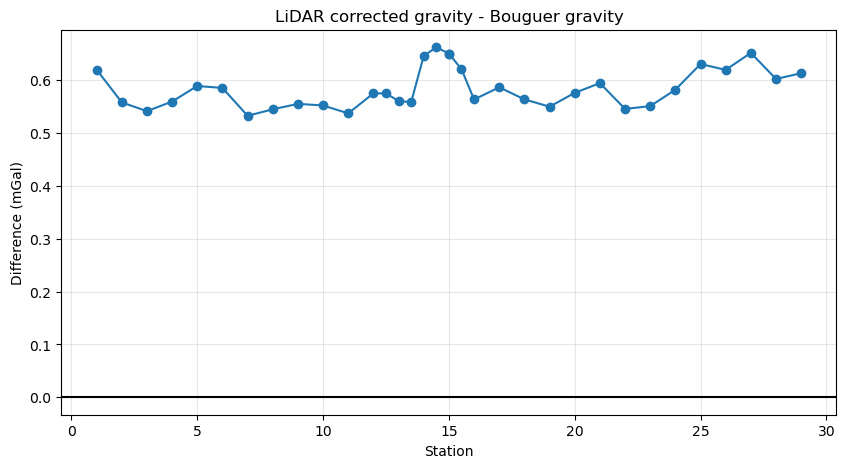

In [22]:
plt.figure(figsize=(10,5))

diff = (
    out["gravity_harmonica_lidar_corrected_mgal"]
    - out["gravity_final_mgal"]
)

plt.plot(out["station"], diff, "o-")
plt.axhline(0, color="k")

plt.xlabel("Station")
plt.ylabel("Difference (mGal)")
plt.title("LiDAR corrected gravity - Bouguer gravity")
plt.grid(True, alpha=0.3)

plt.show()

In [23]:
print(out["harmonica_topography_effect_mgal"].min())
print(out["harmonica_topography_effect_mgal"].max())

print(out["gravity_harmonica_lidar_corrected_mgal"].min())
print(out["gravity_harmonica_lidar_corrected_mgal"].max())

-0.6136211511756898
-0.31861569009041557
0.8493797810201869
1.2304384353571012
